# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [1]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

In [2]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [3]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Time Warping is necessary, or there would be falsely detected functional connection

## Creating ground truth with LIF neurons

In [56]:
from numpy import matlib
def toy_model_fr(features, time_line):
    log_fr_baseline = np.log(features["baseline"])
    log_fr_stimulus = features["bump_amp"] *np.exp(-((time_line-features["bump_center"])/features["bump_wid"])**2)
    log_fr = log_fr_baseline + log_fr_stimulus
    features["log_fr"] = log_fr
    features["fr"] = np.exp(log_fr)

def toy_model_fr_warping(features, time_line):
    log_fr_baseline = np.log(features["baseline"])
    log_fr_stimulus = features["bump_amp"] *np.exp(-((time_line[:, np.newaxis]- \
                                                      features["bump_center"][np.newaxis, :])/features["bump_wid"])**2)
    log_fr = log_fr_baseline + log_fr_stimulus
    features["log_fr"] = log_fr
    features["fr"] = np.exp(log_fr)

def generate_spike_train(fr, rep=1):
    if fr.ndim == 1:
        return np.random.poisson(lam=np.matlib.repmat(fr[:,np.newaxis],1,rep), size=None)
    else:
        return np.random.poisson(lam=np.matlib.repmat(fr,1,rep), size=None)

In [151]:
source = {"baseline": 0.05, "bump_center": np.nan, "bump_amp": 1, "bump_wid": 50}
target = {"baseline": 0.05, "bump_center": np.nan, "bump_amp": 1, "bump_wid": 50}
bump_center_mean = [225, 270]
bump_center_cov = np.array([[2500, 2000], [2000, 2500]])

nneuron = 1
nt = 500 # Say there are 500 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 1000 # 5000 trials in total

spike_trains_source = []
spike_trains_target = []
time_line = np.arange(nt)
bump_centers = np.random.multivariate_normal(bump_center_mean, bump_center_cov, size=ntrial)
source["bump_center"] = bump_centers[:, 0]
target["bump_center"] = bump_centers[:, 1]

for ineuron in range(nneuron):
    toy_model_fr_warping(source, time_line)
    spike_trains_source.append( generate_spike_train(source["fr"]) )
    toy_model_fr_warping(target, time_line)
    spike_trains_target.append( generate_spike_train(target["fr"]) )

Text(0.5, 1.0, 'ground truth firing rate')

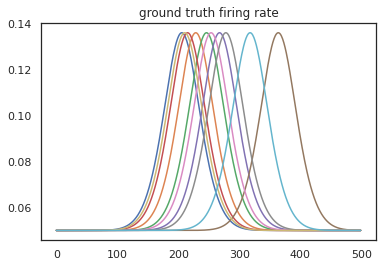

In [152]:
plt.plot(time_line, target["fr"][:, :10])
plt.title('ground truth firing rate')

## Single neuron level model without conditioning on peak timing

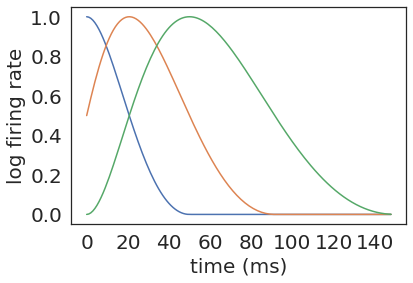

In [132]:
_ = GLM.make_pillow_basis(num=3, peaks_max=50, nonlinear=1, verbose=True)

In [226]:
ntimes = 10

from scipy.stats import ranksums
test_nll_full = []
test_nll_nest = []
test_nll_full_pop = []
test_nll_nest_pop = []

for itimes in tqdm(range(ntimes)):

    source = {"baseline": 0.05, "bump_center": np.nan, "bump_amp": 1.5, "bump_wid": 40}
    target = {"baseline": 0.05, "bump_center": np.nan, "bump_amp": 1.5, "bump_wid": 40}
    bump_center_mean = [240, 260]
    bump_center_cov = np.array([[2500, 2250], [2250, 2500]])

    nneuron = 10
    nt = 500 # Say there are 500 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
    ntrial = 100 # 5000 trials in total

    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    bump_centers = np.random.multivariate_normal(bump_center_mean, bump_center_cov, size=ntrial)
    source["bump_center"] = bump_centers[:, 0]
    target["bump_center"] = bump_centers[:, 1]

    for ineuron in range(nneuron):
        toy_model_fr_warping(source, time_line)
        spike_trains_source.append( generate_spike_train(source["fr"]) )
        toy_model_fr_warping(target, time_line)
        spike_trains_target.append( generate_spike_train(target["fr"]) )

    training_trials = np.array( [True]*int(ntrial*3/4)+[False]*int(ntrial*1/4) )
    test_trials = np.logical_not(training_trials)

    ### Single neuron level model
    for output_spike_train in spike_trains_target:

        model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full.add_effect("inhomogeneous_baseline", num=20)
        for input_spike_train in spike_trains_source:
            model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=50, nonlinear=1)
        model_full.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
        test_nll_full.append( model_full.test(test_trials) )

        model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest.add_effect("inhomogeneous_baseline", num=20)
        model_nest.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
        test_nll_nest.append( model_nest.test(test_trials) )
        
    ### Population level model
    output_spike_train_pool = np.zeros((nt, ntrial))
    for output_spike_train in spike_trains_target:
        output_spike_train_pool += output_spike_train
    input_spike_train_pool = np.zeros((nt, ntrial))
    for input_spike_train in spike_trains_source:
        input_spike_train_pool += input_spike_train

    model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
    model_full.add_effect("inhomogeneous_baseline", num=20)
    model_full.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=50, nonlinear=1)
    model_full.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=10, warp_interval=[[0, 0.5]], 
                                         method='mine', penalty=1e-2, verbose=False)
    test_nll_full_pop.append( model_full.test(test_trials) )

    model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
    model_nest.add_effect("inhomogeneous_baseline", num=20)
    model_nest.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=10, warp_interval=[[0, 0.5]], 
                                         method='mine', penalty=1e-2, verbose=False)
    test_nll_nest_pop.append( model_nest.test(test_trials) )
    
result = ranksums( test_nll_full, test_nll_nest, alternative='less')
result_pop = ranksums( test_nll_full_pop, test_nll_nest_pop, alternative='less')

100%|████████████████████████████████████| 10/10 [03:23<00:00, 20.32s/it]


In [227]:
result

RanksumsResult(statistic=-2.458049220448861, pvalue=0.006984701341684796)

In [228]:
result_pop

RanksumsResult(statistic=-0.5291502622129182, pvalue=0.29835060836467814)

# Sensitivity

In [238]:
ntimes = 10

from scipy.stats import ranksums
test_nll_full = []
test_nll_nest = []
test_nll_full_pop = []
test_nll_nest_pop = []

for itimes in tqdm(range(ntimes)):

    source = {"baseline": 0.05, "bump_center": 240, "bump_amp": 1.5, "bump_wid": 40}
    target = {"baseline": 0.05, "bump_center": 260, "bump_amp": 1.5, "bump_wid": 40}
    
    nneuron = 10
    nt = 500 # Say there are 500 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
    ntrial = 100 # 5000 trials in total
    coupling_decay = 5
    coupling_length = 30
    coupling_strength = 0.01

    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    toy_model_fr(source, time_line)
    toy_model_fr(target, time_line)

    time_line_coupling = np.arange(coupling_length)
    ground_truth_coupling_filter = coupling_strength*np.exp(-time_line_coupling/coupling_decay)
    
    for ineuron in range(nneuron):
        spike_trains_source.append( generate_spike_train(source["fr"], rep=ntrial) )
    input_spike_train_pool = np.zeros((nt, ntrial))
    for input_spike_train in spike_trains_source:
        input_spike_train_pool += input_spike_train
    
    log_lambda_coupling = GLM.conv(input_spike_train_pool, ground_truth_coupling_filter[:, np.newaxis])
    log_lambda_coupling = log_lambda_coupling.reshape((nt, ntrial), order='F')
    target["fr"] = log_lambda_coupling + target["fr"][:, np.newaxis]
    for ineuron in range(nneuron):
        spike_trains_target.append( generate_spike_train(target["fr"]) )

    training_trials = np.array( [True]*int(ntrial*3/4)+[False]*int(ntrial*1/4) )
    test_trials = np.logical_not(training_trials)

    ### Single neuron level model
    for output_spike_train in spike_trains_target:

        model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full.add_effect("inhomogeneous_baseline", num=10)
        for input_spike_train in spike_trains_source:
            model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=50, nonlinear=1)
        model_full.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
        test_nll_full.append( model_full.test(test_trials) )

        model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest.add_effect("inhomogeneous_baseline", num=10)
        model_nest.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
        test_nll_nest.append( model_nest.test(test_trials) )
        
    ### Population level model
    output_spike_train_pool = np.zeros((nt, ntrial))
    for output_spike_train in spike_trains_target:
        output_spike_train_pool += output_spike_train

    model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
    model_full.add_effect("inhomogeneous_baseline", num=10)
    model_full.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=50, nonlinear=1)
    model_full.fit(target=output_spike_train_pool, method='mine', penalty=1e-2, verbose=False)
    test_nll_full_pop.append( model_full.test(test_trials) )

    model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
    model_nest.add_effect("inhomogeneous_baseline", num=10)
    model_nest.fit(target=output_spike_train_pool, method='mine', penalty=1e-2, verbose=False)
    test_nll_nest_pop.append( model_nest.test(test_trials) )
    
result = ranksums( test_nll_full, test_nll_nest, alternative='less')
result_pop = ranksums( test_nll_full_pop, test_nll_nest_pop, alternative='less')

100%|████████████████████████████████████| 10/10 [00:18<00:00,  1.82s/it]


In [239]:
result

RanksumsResult(statistic=-1.5759858321963374, pvalue=0.057514534178149876)

In [240]:
result_pop

RanksumsResult(statistic=-3.6284589408885815, pvalue=0.00014255904181580633)

Text(0.5, 1.0, 'ground truth $\\gamma_{2,1,:}$')

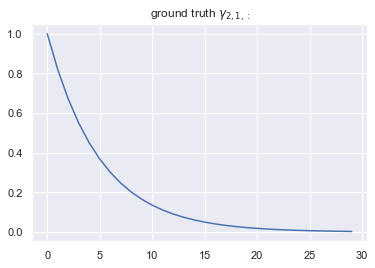

In [5]:
coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = np.exp(-time_line_coupling/5)
plt.plot(ground_truth_coupling_filter)
plt.title('ground truth $\gamma_{2,1,:}$')

In [6]:

log_lambda_neuron2 = log_lambda_baseline + 0.5*log_lambda_stimulus[:,np.newaxis] + log_lambda_coupling
lambda_neuron2 = np.exp(log_lambda_neuron2)

If we look at the log lambda of a given trial, we can see the firing rate of neuron 2 suddenly jump up when neuron 1 spikes. 

Text(0.5, 1.0, 'log firing rate of an example trial')

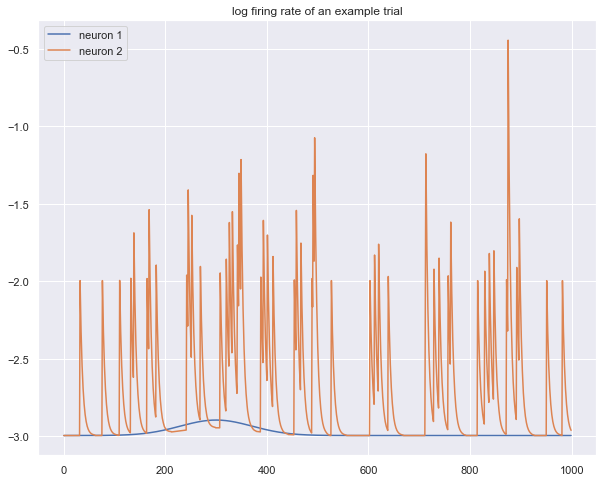

In [10]:
plt.subplots(figsize=(10,8))
plt.plot(log_lambda_neuron1, label='neuron 1')
plt.plot(log_lambda_neuron2[:,0], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')